# Boggle 5x5 Solver Showdown

Benchmark objective: maximize **validated score** with **lowest runtime** as tie-breaker.

Rules:
- Board size: `5x5` (duplicate letters allowed)
- Minimum word length: `3`
- Unique words only
- Base score per word: `len(word) - 2` (3 -> 1, 4 -> 2, 5 -> 3, ...)
- Multi-letter tiles (e.g. `HE`, `TH`, `QU`) allowed; each used tile adds `+0.5`
- At most `2` multi-letter tiles per board
- One marked bonus node may exist; using it in a word adds `+1.0`
- Per-solver time cap: `10.0` seconds per board
- Winner: highest average validated score, then lowest average runtime



In [11]:
import time
import random
import string
import heapq
import inspect
import textwrap
import urllib.request
from pathlib import Path
from functools import lru_cache
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

BOARD_SIZE = 5
MIN_WORD_LEN = 3
TIME_BUDGET_SECONDS = 10.0
NUM_TRIALS = 500
RNG_SEED = 1337

WORDS_URL = "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt"
WORDS_PATH = Path("words.txt")

MAX_SPECIAL_NODES = 2
BONUS_NODE_PROBABILITY = 1.0
DIGRAPH_TOKENS = ["QU", "TH", "HE", "IN", "ER", "AN", "RE", "ON", "AT", "EN"]

LETTER_WEIGHT = {
    "E": 0.2, "T": 0.3, "A": 0.3, "O": 0.3, "I": 0.4, "N": 0.4,
    "S": 0.5, "H": 0.5, "R": 0.5, "D": 0.7, "L": 0.7, "C": 0.8,
    "U": 0.8, "M": 0.9, "W": 1.0, "F": 1.1, "G": 1.1, "Y": 1.2,
    "P": 1.2, "B": 1.3, "V": 1.4, "K": 1.5, "J": 2.0, "X": 2.1,
    "Q": 2.2, "Z": 2.3,
}



In [12]:
def ensure_word_list(path=WORDS_PATH, url=WORDS_URL):
    if not path.exists():
        print(f"Downloading word list to {path} ...")
        urllib.request.urlretrieve(url, path)
    return path


def load_words_from_file(path, min_len=MIN_WORD_LEN):
    words = set()
    with open(path, "r", encoding="utf-8") as f:
        for raw in f:
            word = raw.strip().upper()
            if len(word) >= min_len and word.isalpha():
                words.add(word)
    return words


ensure_word_list()
ALL_WORDS = load_words_from_file(WORDS_PATH)
print(f"Loaded {len(ALL_WORDS):,} words (len >= {MIN_WORD_LEN})")


Loaded 369,652 words (len >= 3)


In [13]:
def build_prefixes(words):
    prefixes = set()
    for w in words:
        for i in range(1, len(w) + 1):
            prefixes.add(w[:i])
    return prefixes


class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end = False


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
        node.is_end = True


def build_trie(words):
    trie = Trie()
    for w in words:
        trie.insert(w)
    return trie


def prepare_solver_resources(words):
    return {
        "all_words": words,
        "prefixes": build_prefixes(words),
        "trie": build_trie(words),
        "max_word_len": max(len(w) for w in words),
        "letter_weight": LETTER_WEIGHT,
    }


GLOBAL_RESOURCES = prepare_solver_resources(ALL_WORDS)
print("Prefix set and trie built.")


Prefix set and trie built.


In [14]:
def score_word(word):
    return max(0, len(word) - 2)


def _token_weight(token, letter_weight):
    if not token:
        return 1.0
    return sum(letter_weight.get(ch, 1.0) for ch in token) / len(token)


def flatten_grid(grid):
    return [ch for row in grid for ch in row]


def serialize_grid(grid):
    return "|".join(",".join(row) for row in grid)


def serialize_board(board):
    grid = board["grid"]
    digraph_indices = set(board.get("digraph_indices", set()))
    bonus_index = board.get("bonus_index")
    size = len(grid)
    rows = []
    for r in range(size):
        cells = []
        for c in range(size):
            idx = r * size + c
            token = grid[r][c]
            suffix = ""
            if idx in digraph_indices:
                suffix += "~"
            if bonus_index is not None and idx == bonus_index:
                suffix += "*"
            cells.append(f"{token}{suffix}")
        rows.append(",".join(cells))
    return "|".join(rows)


def build_neighbors(size):
    neighbors = [[] for _ in range(size * size)]
    for r in range(size):
        for c in range(size):
            idx = r * size + c
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == 0 and dc == 0:
                        continue
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < size and 0 <= nc < size:
                        neighbors[idx].append(nr * size + nc)
    return neighbors


def generate_random_grid(size=BOARD_SIZE, rng=None):
    rng = rng or random
    letters = string.ascii_uppercase
    return [[rng.choice(letters) for _ in range(size)] for _ in range(size)]


def generate_random_board(
    size=BOARD_SIZE,
    rng=None,
    max_special_nodes=MAX_SPECIAL_NODES,
    digraph_tokens=DIGRAPH_TOKENS,
    bonus_probability=BONUS_NODE_PROBABILITY,
):
    rng = rng or random
    grid = generate_random_grid(size=size, rng=rng)
    n = size * size

    special_count = rng.randint(0, max_special_nodes)
    special_indices = set(rng.sample(range(n), k=special_count)) if special_count else set()
    for idx in special_indices:
        r, c = divmod(idx, size)
        grid[r][c] = rng.choice(digraph_tokens)

    bonus_index = rng.randrange(n) if rng.random() <= bonus_probability else None
    return {
        "grid": grid,
        "digraph_indices": special_indices,
        "bonus_index": bonus_index,
    }


def make_board_word_matcher(grid, neighbors, digraph_indices=None, bonus_index=None):
    tokens = flatten_grid(grid)
    n = len(tokens)
    digraph_set = set(digraph_indices or set())

    starts_by_char = defaultdict(list)
    for i, tok in enumerate(tokens):
        if tok:
            starts_by_char[tok[0]].append(i)

    def tile_bonus(idx):
        b = 0.0
        if idx in digraph_set:
            b += 0.5
        if bonus_index is not None and idx == bonus_index:
            b += 1.0
        return b

    @lru_cache(maxsize=None)
    def best_bonus(word):
        if not word:
            return None

        @lru_cache(maxsize=None)
        def dfs(last_idx, pos, mask):
            if pos == len(word):
                return 0.0

            best_val = None
            for nb in neighbors[last_idx]:
                bit = 1 << nb
                if mask & bit:
                    continue
                tok = tokens[nb]
                if not word.startswith(tok, pos):
                    continue
                nxt = dfs(nb, pos + len(tok), mask | bit)
                if nxt is None:
                    continue
                cand = tile_bonus(nb) + nxt
                if best_val is None or cand > best_val:
                    best_val = cand
            return best_val

        best_val = None
        for start in starts_by_char.get(word[0], []):
            tok = tokens[start]
            if not word.startswith(tok, 0):
                continue

            consumed = len(tok)
            base = tile_bonus(start)
            if consumed == len(word):
                cand = base
            else:
                nxt = dfs(start, consumed, 1 << start)
                if nxt is None:
                    continue
                cand = base + nxt

            if best_val is None or cand > best_val:
                best_val = cand

        return best_val

    return best_bonus


def validate_candidates(candidates, grid, all_words, neighbors, digraph_indices=None, bonus_index=None):
    raw = []
    for w in candidates:
        if isinstance(w, str):
            s = w.strip().upper()
            if s:
                raw.append(s)

    unique = set(raw)
    matcher = make_board_word_matcher(
        grid,
        neighbors,
        digraph_indices=digraph_indices,
        bonus_index=bonus_index,
    )

    valid = set()
    invalid_rejected = 0
    bonus_points_total = 0.0
    score_total = 0.0
    for word in unique:
        if len(word) < MIN_WORD_LEN:
            invalid_rejected += 1
            continue
        if word not in all_words:
            invalid_rejected += 1
            continue

        bonus = matcher(word)
        if bonus is None:
            invalid_rejected += 1
            continue

        valid.add(word)
        bonus_points_total += bonus
        score_total += score_word(word) + bonus

    duplicate_rejected = max(0, len(raw) - len(unique))
    return {
        "valid_words": valid,
        "score": score_total,
        "bonus_points": bonus_points_total,
        "raw_count": len(raw),
        "valid_count": len(valid),
        "invalid_rejected": invalid_rejected,
        "duplicate_rejected": duplicate_rejected,
    }



In [15]:
def _trie_advance(node, token):
    cur = node
    for ch in token:
        cur = cur.children.get(ch)
        if cur is None:
            return None
    return cur


def solve_exact_trie_dfs(grid, deadline, resources):
    tiles = flatten_grid(grid)
    neighbors = resources["neighbors"]
    trie_root = resources["trie"].root
    max_word_len = resources["max_word_len"]

    found = set()
    steps = 0

    def dfs(idx, node, mask, path):
        nonlocal steps
        steps += 1
        if steps % 128 == 0 and time.perf_counter() >= deadline:
            return

        token = tiles[idx]
        next_node = _trie_advance(node, token)
        if next_node is None:
            return

        word = path + token
        if next_node.is_end and len(word) >= MIN_WORD_LEN:
            found.add(word)

        if len(word) >= max_word_len:
            return

        new_mask = mask | (1 << idx)
        for nb in neighbors[idx]:
            if new_mask & (1 << nb):
                continue
            if _trie_advance(next_node, tiles[nb]) is not None:
                dfs(nb, next_node, new_mask, word)

    for start in range(len(tiles)):
        if time.perf_counter() >= deadline:
            break
        if _trie_advance(trie_root, tiles[start]) is not None:
            dfs(start, trie_root, 0, "")

    return found



In [16]:
def solve_prefixset_dfs_baseline(grid, deadline, resources):
    tiles = flatten_grid(grid)
    neighbors = resources["neighbors"]
    prefixes = resources["prefixes"]
    all_words = resources["all_words"]
    max_word_len = resources["max_word_len"]

    found = set()
    steps = 0

    def dfs(idx, mask, path):
        nonlocal steps
        steps += 1
        if steps % 128 == 0 and time.perf_counter() >= deadline:
            return

        word = path + tiles[idx]
        if word not in prefixes:
            return

        if len(word) >= MIN_WORD_LEN and word in all_words:
            found.add(word)

        if len(word) >= max_word_len:
            return

        new_mask = mask | (1 << idx)
        for nb in neighbors[idx]:
            if new_mask & (1 << nb):
                continue
            dfs(nb, new_mask, word)

    for start in range(len(tiles)):
        if time.perf_counter() >= deadline:
            break
        dfs(start, 0, "")

    return found



In [17]:
def solve_heuristic_beam_search(grid, deadline, resources, beam_width=1400, max_states=90000):
    tiles = flatten_grid(grid)
    neighbors = resources["neighbors"]
    prefixes = resources["prefixes"]
    all_words = resources["all_words"]
    max_word_len = resources["max_word_len"]
    letter_weight = resources["letter_weight"]

    found = set()
    heap = []

    for idx, token in enumerate(tiles):
        if token in prefixes:
            base_priority = -(_token_weight(token, letter_weight) + 0.2 * len(neighbors[idx]))
            heapq.heappush(heap, (base_priority, idx, 1 << idx, token))

    seen = set()
    states = 0
    while heap and states < max_states and time.perf_counter() < deadline:
        priority, idx, mask, word = heapq.heappop(heap)
        key = (idx, word)
        if key in seen:
            continue
        seen.add(key)
        states += 1

        if len(word) >= MIN_WORD_LEN and word in all_words:
            found.add(word)

        if len(word) >= max_word_len:
            continue

        children = []
        for nb in neighbors[idx]:
            bit = 1 << nb
            if mask & bit:
                continue
            next_word = word + tiles[nb]
            if next_word not in prefixes:
                continue

            immediate = max(0, len(next_word) - 2)
            expansion_bonus = 0.25 * len(neighbors[nb])
            rarity_bonus = _token_weight(tiles[nb], letter_weight)
            score_hint = (3.0 * immediate) + expansion_bonus + rarity_bonus
            children.append((-score_hint, nb, mask | bit, next_word))

        children.sort(key=lambda x: x[0])
        for child in children[:8]:
            heapq.heappush(heap, child)

        if len(heap) > beam_width:
            heap = heapq.nsmallest(beam_width, heap)
            heapq.heapify(heap)

    return found



In [18]:
def solve_monte_carlo_guided_search(grid, deadline, resources, max_walk_len=12):
    tiles = flatten_grid(grid)
    neighbors = resources["neighbors"]
    prefixes = resources["prefixes"]
    all_words = resources["all_words"]
    letter_weight = resources["letter_weight"]

    board_seed = hash(tuple(tiles)) & 0xFFFFFFFF
    rng = random.Random(RNG_SEED ^ board_seed)

    found = set()
    n = len(tiles)

    while time.perf_counter() < deadline:
        idx = rng.randrange(n)
        word = tiles[idx]
        if word not in prefixes:
            continue
        mask = 1 << idx

        if len(word) >= MIN_WORD_LEN and word in all_words:
            found.add(word)

        for _ in range(max_walk_len - 1):
            if time.perf_counter() >= deadline:
                break

            options = []
            for nb in neighbors[idx]:
                bit = 1 << nb
                if mask & bit:
                    continue

                next_word = word + tiles[nb]
                if next_word not in prefixes:
                    continue

                gain = max(0, len(next_word) - 2)
                w = 1.0 + (0.35 * gain) + _token_weight(tiles[nb], letter_weight)
                options.append((nb, next_word, bit, w))

            if not options:
                break

            total = sum(opt[3] for opt in options)
            pick = rng.random() * total
            acc = 0.0
            chosen = options[-1]
            for opt in options:
                acc += opt[3]
                if pick <= acc:
                    chosen = opt
                    break

            idx, word, bit, _ = chosen
            mask |= bit
            if len(word) >= MIN_WORD_LEN and word in all_words:
                found.add(word)

    return found



Solver tasks: 100%|██████████| 2000/2000 [05:29<00:00,  6.08it/s]  


,solver,avg_score,median_score,avg_bonus,avg_runtime,median_runtime,avg_score_per_second,avg_valid_words,avg_invalid,avg_duplicates
0,Exact_Trie_DFS,279.919,232.50,28.913,0.012950,0.002522,93552.017763,141.930,0.0,0.0
1,PrefixSet_DFS_Baseline,279.919,232.50,28.913,0.042496,0.002592,78226.817371,141.930,0.0,0.0
2,MonteCarlo_Guided_Search,274.677,228.25,28.537,10.214071,10.133127,26.877439,140.422,0.0,0.0
3,Heuristic_Beam_Search,273.709,229.25,28.455,0.067387,0.004673,46060.140075,139.924,0.0,0.0


,trial,solver,validated_score,runtime_seconds
0,1,PrefixSet_DFS_Baseline,95.0,0.001082
1,2,Exact_Trie_DFS,138.5,0.001155
2,3,PrefixSet_DFS_Baseline,260.0,0.002273
3,4,Exact_Trie_DFS,63.5,0.000655
4,5,Exact_Trie_DFS,622.5,0.005415
...,...,...,...,...
495,496,PrefixSet_DFS_Baseline,320.0,0.003346
496,497,PrefixSet_DFS_Baseline,399.0,0.001983
497,498,Exact_Trie_DFS,403.5,0.002604
498,499,Exact_Trie_DFS,460.0,0.005105


WINNER: Exact_Trie_DFS (highest average score, fastest tie-break)


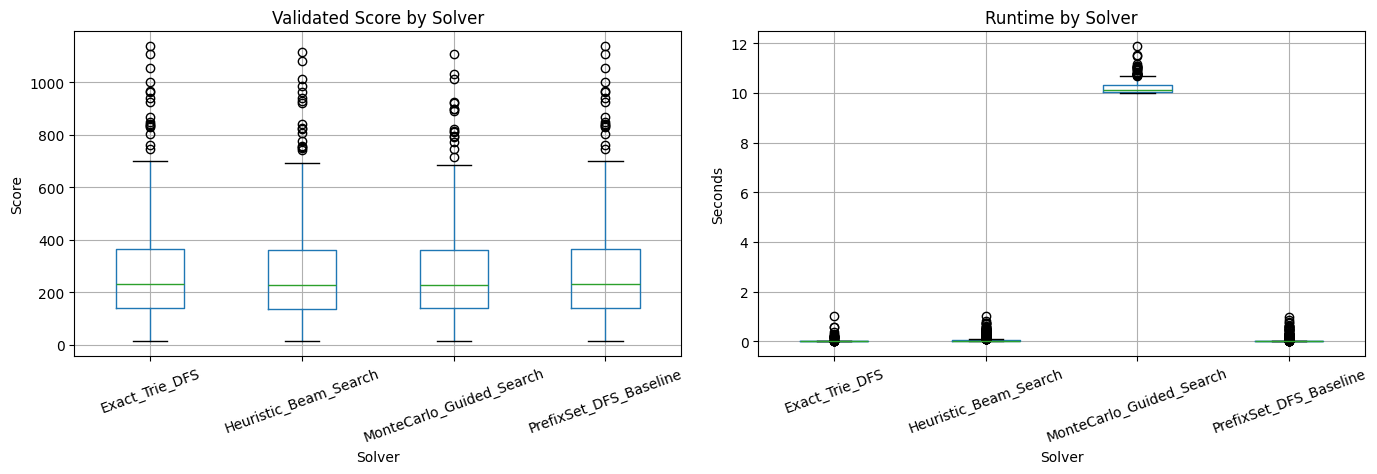

Exported winner module: boggle_winner.py


In [19]:
SOLVERS = {
    "Exact_Trie_DFS": solve_exact_trie_dfs,
    "PrefixSet_DFS_Baseline": solve_prefixset_dfs_baseline,
    "Heuristic_Beam_Search": solve_heuristic_beam_search,
    "MonteCarlo_Guided_Search": solve_monte_carlo_guided_search,
}


def _build_resources_with_neighbors(neighbors):
    return {
        "all_words": GLOBAL_RESOURCES["all_words"],
        "prefixes": GLOBAL_RESOURCES["prefixes"],
        "trie": GLOBAL_RESOURCES["trie"],
        "max_word_len": GLOBAL_RESOURCES["max_word_len"],
        "letter_weight": GLOBAL_RESOURCES["letter_weight"],
        "neighbors": neighbors,
    }


def _run_solver_task(task):
    trial, board_key, grid, digraph_indices, bonus_index, solver_name, time_budget, neighbors = task
    solver = SOLVERS[solver_name]
    resources = _build_resources_with_neighbors(neighbors)

    start = time.perf_counter()
    deadline = start + time_budget
    candidates = solver(grid, deadline, resources)
    runtime = time.perf_counter() - start

    report = validate_candidates(
        candidates,
        grid,
        resources["all_words"],
        neighbors,
        digraph_indices=digraph_indices,
        bonus_index=bonus_index,
    )
    score_per_second = report["score"] / max(runtime, 1e-9)

    return {
        "trial": trial,
        "board": board_key,
        "solver": solver_name,
        "runtime_seconds": runtime,
        "raw_candidates": report["raw_count"],
        "valid_unique_words": report["valid_count"],
        "validated_score": report["score"],
        "bonus_points": report["bonus_points"],
        "score_per_second": score_per_second,
        "invalid_rejected": report["invalid_rejected"],
        "duplicate_rejected": report["duplicate_rejected"],
        "digraph_nodes": len(digraph_indices),
        "bonus_node_present": 1 if bonus_index is not None else 0,
    }


def _run_tasks_parallel(tasks, max_workers=None):
    from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
    import multiprocessing as mp

    try:
        methods = set(mp.get_all_start_methods())
    except Exception:
        methods = set()

    if "fork" in methods:
        ctx = mp.get_context("fork")
        with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as ex:
            futures = [ex.submit(_run_solver_task, task) for task in tasks]
            rows = []
            for future in tqdm(as_completed(futures), total=len(futures), desc="Solver tasks"):
                rows.append(future.result())
            return rows

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_run_solver_task, task) for task in tasks]
        rows = []
        for future in tqdm(as_completed(futures), total=len(futures), desc="Solver tasks"):
            rows.append(future.result())
        return rows


def run_benchmark(
    num_trials=NUM_TRIALS,
    grid_size=BOARD_SIZE,
    time_budget=TIME_BUDGET_SECONDS,
    seed=RNG_SEED,
    parallel=True,
    max_workers=None,
):
    rng = random.Random(seed)
    neighbors = build_neighbors(grid_size)

    tasks = []
    for trial in tqdm(range(1, num_trials + 1), desc="Boards"):
        board = generate_random_board(size=grid_size, rng=rng)
        board_key = serialize_board(board)
        grid = board["grid"]
        digraph_indices = board["digraph_indices"]
        bonus_index = board["bonus_index"]

        for solver_name in SOLVERS:
            tasks.append((trial, board_key, grid, digraph_indices, bonus_index, solver_name, time_budget, neighbors))

    if parallel:
        rows = _run_tasks_parallel(tasks, max_workers=max_workers)
    else:
        rows = [_run_solver_task(task) for task in tqdm(tasks, desc="Solver tasks")]

    return pd.DataFrame(rows)


def summarize_results(df):
    summary = (
        df.groupby("solver", as_index=False)
        .agg(
            avg_score=("validated_score", "mean"),
            median_score=("validated_score", "median"),
            avg_bonus=("bonus_points", "mean"),
            avg_runtime=("runtime_seconds", "mean"),
            median_runtime=("runtime_seconds", "median"),
            avg_score_per_second=("score_per_second", "mean"),
            avg_valid_words=("valid_unique_words", "mean"),
            avg_invalid=("invalid_rejected", "mean"),
            avg_duplicates=("duplicate_rejected", "mean"),
        )
        .sort_values(["avg_score", "avg_runtime"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return summary


def _update_registry_from_source(registry, source):
    import ast

    if not source or not source.strip():
        return
    try:
        tree = ast.parse(source)
    except SyntaxError:
        return

    lines = source.splitlines()
    for node in tree.body:
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
            start = max(0, node.lineno - 1)
            end = getattr(node, "end_lineno", node.lineno)
            snippet = "\n".join(lines[start:end]).strip()
            if snippet:
                registry[node.name] = snippet


def _build_source_registry():
    import json

    registry = {}

    try:
        from IPython import get_ipython

        ip = get_ipython()
        if ip is not None:
            for block in ip.user_ns.get("In", []):
                _update_registry_from_source(registry, block)
    except Exception:
        pass

    nb_path = Path("boggle_solver_benchmark.ipynb")
    if nb_path.exists():
        try:
            nb = json.loads(nb_path.read_text(encoding="utf-8"))
            for cell in nb.get("cells", []):
                if cell.get("cell_type") == "code":
                    _update_registry_from_source(registry, "".join(cell.get("source", [])))
        except Exception:
            pass

    return registry


def _safe_get_source(name, obj, registry):
    try:
        return textwrap.dedent(inspect.getsource(obj)).strip()
    except (OSError, TypeError):
        candidate = registry.get(name) or registry.get(getattr(obj, "__name__", ""))
        if candidate:
            return candidate.strip()
        raise RuntimeError(
            f"Unable to extract source for '{name}'. Re-run defining cells, then retry export."
        )


def export_winner_module(winner_name, out_path="boggle_winner.py"):
    object_map = {
        "ensure_word_list": ensure_word_list,
        "load_words_from_file": load_words_from_file,
        "build_prefixes": build_prefixes,
        "TrieNode": TrieNode,
        "Trie": Trie,
        "build_trie": build_trie,
        "prepare_solver_resources": prepare_solver_resources,
        "score_word": score_word,
        "_token_weight": _token_weight,
        "flatten_grid": flatten_grid,
        "serialize_grid": serialize_grid,
        "serialize_board": serialize_board,
        "build_neighbors": build_neighbors,
        "generate_random_grid": generate_random_grid,
        "generate_random_board": generate_random_board,
        "make_board_word_matcher": make_board_word_matcher,
        "validate_candidates": validate_candidates,
        "_trie_advance": _trie_advance,
        "solve_exact_trie_dfs": solve_exact_trie_dfs,
        "solve_prefixset_dfs_baseline": solve_prefixset_dfs_baseline,
        "solve_heuristic_beam_search": solve_heuristic_beam_search,
        "solve_monte_carlo_guided_search": solve_monte_carlo_guided_search,
    }

    common_names = [
        "ensure_word_list",
        "load_words_from_file",
        "build_prefixes",
        "TrieNode",
        "Trie",
        "build_trie",
        "prepare_solver_resources",
        "score_word",
        "_token_weight",
        "flatten_grid",
        "serialize_grid",
        "serialize_board",
        "build_neighbors",
        "generate_random_grid",
        "generate_random_board",
        "make_board_word_matcher",
        "validate_candidates",
        "_trie_advance",
    ]

    solver_name_map = {
        "Exact_Trie_DFS": "solve_exact_trie_dfs",
        "PrefixSet_DFS_Baseline": "solve_prefixset_dfs_baseline",
        "Heuristic_Beam_Search": "solve_heuristic_beam_search",
        "MonteCarlo_Guided_Search": "solve_monte_carlo_guided_search",
    }

    chosen_solver_fn_name = solver_name_map[winner_name]
    export_names = common_names + [chosen_solver_fn_name]
    source_registry = _build_source_registry()

    lines = []
    lines.append("# BOGGLE SOLVER - WINNING VERSION\n")
    lines.append("# Generated automatically by boggle_solver_benchmark.ipynb\n\n")
    lines.append("import time\n")
    lines.append("import random\n")
    lines.append("import string\n")
    lines.append("import heapq\n")
    lines.append("import urllib.request\n")
    lines.append("from pathlib import Path\n")
    lines.append("from functools import lru_cache\n")
    lines.append("from collections import defaultdict\n\n")
    lines.append(f"BOARD_SIZE = {BOARD_SIZE}\n")
    lines.append(f"MIN_WORD_LEN = {MIN_WORD_LEN}\n")
    lines.append(f"TIME_BUDGET_SECONDS = {TIME_BUDGET_SECONDS}\n")
    lines.append(f"RNG_SEED = {RNG_SEED}\n")
    lines.append(f"MAX_SPECIAL_NODES = {MAX_SPECIAL_NODES}\n")
    lines.append(f"BONUS_NODE_PROBABILITY = {BONUS_NODE_PROBABILITY}\n")
    lines.append(f"DIGRAPH_TOKENS = {repr(DIGRAPH_TOKENS)}\n")
    lines.append("WORDS_URL = \"https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt\"\n")
    lines.append("WORDS_PATH = Path(\"words.txt\")\n")
    lines.append(f"LETTER_WEIGHT = {repr(LETTER_WEIGHT)}\n\n")

    for name in export_names:
        src = _safe_get_source(name, object_map[name], source_registry)
        lines.append(src + "\n\n")

    lines.append(f"WINNER_NAME = {winner_name!r}\n")
    lines.append(f"WINNER_SOLVER = {chosen_solver_fn_name}\n\n")

    lines.append(
        "def solve_board(board, words_path=WORDS_PATH, time_budget=TIME_BUDGET_SECONDS):\n"
        "    resources = prepare_solver_resources(load_words_from_file(ensure_word_list(words_path)))\n"
        "    if isinstance(board, dict):\n"
        "        grid = board['grid']\n"
        "        digraph_indices = board.get('digraph_indices', set())\n"
        "        bonus_index = board.get('bonus_index')\n"
        "    else:\n"
        "        grid = board\n"
        "        digraph_indices = set()\n"
        "        bonus_index = None\n"
        "    resources['neighbors'] = build_neighbors(len(grid))\n"
        "    deadline = time.perf_counter() + time_budget\n"
        "    candidates = WINNER_SOLVER(grid, deadline, resources)\n"
        "    return validate_candidates(candidates, grid, resources['all_words'], resources['neighbors'], digraph_indices=digraph_indices, bonus_index=bonus_index)\n\n"
    )

    lines.append(
        "if __name__ == '__main__':\n"
        "    b = generate_random_board()\n"
        "    result = solve_board(b)\n"
        "    print('Board:')\n"
        "    for row in b['grid']:\n"
        "        print(' '.join(row))\n"
        "    print('Board key:', serialize_board(b))\n"
        "    print('Winner solver:', WINNER_NAME)\n"
        "    print('Valid unique words:', result['valid_count'])\n"
        "    print('Bonus points:', result['bonus_points'])\n"
        "    print('Score:', result['score'])\n"
    )

    Path(out_path).write_text("".join(lines), encoding="utf-8")
    return out_path


benchmark_df = run_benchmark(num_trials=NUM_TRIALS, parallel=True)
summary_df = summarize_results(benchmark_df)
display(summary_df)

trial_best = (
    benchmark_df.sort_values(["trial", "validated_score", "runtime_seconds"], ascending=[True, False, True])
    .groupby("trial", as_index=False)
    .first()
)
display(trial_best[["trial", "solver", "validated_score", "runtime_seconds"]])

winner_name = summary_df.iloc[0]["solver"]
print(f"WINNER: {winner_name} (highest average score, fastest tie-break)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
benchmark_df.boxplot(column="validated_score", by="solver", ax=axes[0], rot=20)
axes[0].set_title("Validated Score by Solver")
axes[0].set_xlabel("Solver")
axes[0].set_ylabel("Score")

benchmark_df.boxplot(column="runtime_seconds", by="solver", ax=axes[1], rot=20)
axes[1].set_title("Runtime by Solver")
axes[1].set_xlabel("Solver")
axes[1].set_ylabel("Seconds")

plt.suptitle("")
plt.tight_layout()
plt.show()

export_path = export_winner_module(winner_name, out_path="boggle_winner.py")
print(f"Exported winner module: {export_path}")

